In [1]:
import os
import pandas as pd
import seaborn as sns
import scanpy as sc
import matplotlib.pyplot as plt
from matplotlib import rc_context

In [2]:
dir_path = "/home/wu/datb1/AutoExtractSingleCell/01.benchmark_datasets/all_time_benchmark/output_deepseek"
merge_df = pd.DataFrame()
for file in os.listdir(dir_path):
    if file.endswith("_log.txt"):
        df = {}
        with open(os.path.join(dir_path, file), "r") as f:
            lines = f.readlines()
            for line in lines:
                key, value = line.strip().split(": ")
                if 'seconds' in value:
                    value = float(value.replace(' seconds', ''))
                df[key] = value
        df = pd.DataFrame(df, index=[0])
        merge_df = pd.concat([merge_df, df], axis=0)
        
merge_df['total time'] = merge_df.loc[:, merge_df.columns.str.contains('time')].sum(axis=1).astype(int)
merge_df['Cell number'] = merge_df['Cell number'].astype(int)
merge_df['total time'] = merge_df['total time'] / 60
merge_df['Cell number'] = merge_df['Cell number'] / 1000
merge_df.set_index('Sample name', inplace=True)

In [3]:
merge_df

,Cell number,Cluster number,Reading time,Agent initial time,Agent filter time,Filtering time,Agent preprocess time,Preprocessing time,Agent clustering time,Clustering time,Get marker genes time,Agent annotate time,Annotation time,Writing time,total time
Sample name,,,,,,,,,,,,,,,
sample12,49.947,9,1.29,6.97,15.30,4.33,16.31,148.95,11.77,26.38,124.92,31.18,0.01,1.82,6.483333
sample8,23.985,11,4.65,14.40,14.85,5.07,13.26,70.44,17.31,11.78,53.78,28.92,0.00,1.56,3.933333
sample9,26.845,19,6.53,20.56,18.30,4.03,20.18,40.31,15.45,22.64,79.16,37.70,0.01,1.68,4.433333
sample21,41.648,19,16.68,15.57,11.56,4.44,13.49,121.19,13.26,30.65,128.98,40.13,0.01,2.14,6.633333
sample17,50.901,11,9.09,15.17,14.56,7.41,12.86,125.75,14.94,23.41,115.84,33.11,0.01,6.37,6.300000
sample20,31.499,12,4.38,34.16,16.46,4.25,15.58,132.25,17.91,15.49,100.57,42.38,0.01,1.95,6.416667
sample11,10.489,12,1.59,12.65,16.86,1.47,18.50,40.22,17.79,4.25,13.96,25.96,0.00,0.68,2.550000
sample3,30.120,25,4.03,16.99,15.66,8.80,15.43,79.51,15.80,25.63,168.71,36.23,0.01,1.79,6.466667
sample18,69.108,16,12.29,7.23,15.11,6.25,15.11,251.85,12.89,60.22,283.51,34.34,0.02,64.10,12.700000


In [4]:
sns.set_style("white")

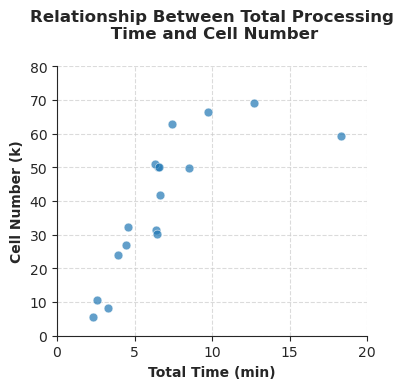

In [5]:
with plt.rc_context(rc={"figure.figsize": (4, 3.5)}):
    g = sns.scatterplot(
        data=merge_df,
        x='total time',
        y='Cell number',
        color='#1f77b4',
        alpha=0.7,
        s=40,
    )
    
    g.set_xlabel("Total Time (min)", fontweight='bold')
    g.set_ylabel("Cell Number (k)", fontweight='bold')
    
    g.set_title("Relationship Between Total Processing\n Time and Cell Number", 
                fontweight='bold', pad=20)
    g.set_xlim(0, 20)
    g.set_ylim(0, 80)
    g.yaxis.set_ticks_position('left')
    g.xaxis.set_ticks_position('bottom')
    g.grid(True, linestyle='--', alpha=0.7)
    sns.despine()
    plt.savefig("figures_revision/total_time_cell_number.pdf", bbox_inches='tight')
    plt.show()
    

In [18]:
df_new = pd.read_csv("scripts_revision/new_version.csv")
df_old = pd.read_csv("scripts_revision/old_version.csv")
df_old['processing_time'] = df_old['processing_time'].astype(float)
df_new['processing_time'] = df_new['processing_time'].astype(float)


In [19]:
df_new.rename(columns={'processing_time': 'total time (improved)'}, inplace=True)
df_new['total time (original)'] = df_old['processing_time']

In [24]:
df = df_new.melt(id_vars=['file_name'], value_vars=['total time (improved)', 'total time (original)'],
          var_name='version', value_name='total time')

/tmp/ipykernel_2571843/2320112104.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.boxplot(data=df, x='version', y='total time', palette=['#1f77b4', '#ff7f0e'], width=0.5,
/tmp/ipykernel_2571843/2320112104.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=df, x='version', y='total time', palette=['#1f77b4', '#ff7f0e'], size=5, alpha=0.7, edgecolor='black')
/tmp/ipykernel_2571843/2320112104.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels(['v1.11.1', 'v1.11.0'], fontweight='bold')


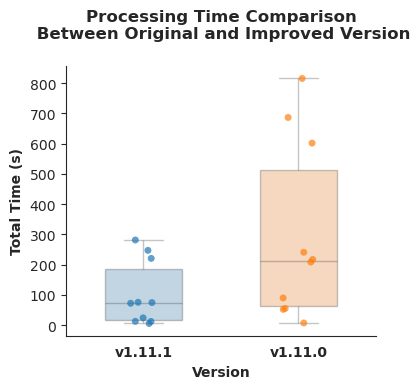

In [52]:
plt.figure(figsize=(4, 3.5))
g = sns.boxplot(data=df, x='version', y='total time', palette=['#1f77b4', '#ff7f0e'], width=0.5,
            boxprops={'alpha': 0.3},
            whiskerprops={'alpha': 0.3},
            capprops={'alpha': 0.3},
            medianprops={'alpha': 0.3})
sns.stripplot(data=df, x='version', y='total time', palette=['#1f77b4', '#ff7f0e'], size=5, alpha=0.7, edgecolor='black')
sns.despine()

plt.title("Processing Time Comparison\n Between Original and Improved Version", fontweight='bold', pad=20)
plt.xlabel("Version", fontweight='bold')
g.set_xticklabels(['v1.11.1', 'v1.11.0'], fontweight='bold')
plt.ylabel("Total Time (s)", fontweight='bold')
g.yaxis.set_ticks_position('left')
plt.show()
